## Partie 3 — Évaluation, interprétabilité & application finale

### 1. Évaluation avancée


#### Matrice de confusion


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import roc_auc_score

In [6]:
def confusion_matrix(y_true, y_pred):
    """
    Compute the confusion matrix for binary classification.

    Parameters:
    y_true (list): True labels (0 or 1).
    y_pred (list): Predicted labels (0 or 1).

    Returns:
    dict: A dictionary containing TP, TN, FP, and FN.
    """
    TP = sum((y_true[i] == 1 and y_pred[i] == 1) for i in range(len(y_true)))
    TN = sum((y_true[i] == 0 and y_pred[i] == 0) for i in range(len(y_true)))
    FP = sum((y_true[i] == 0 and y_pred[i] == 1) for i in range(len(y_true)))
    FN = sum((y_true[i] == 1 and y_pred[i] == 0) for i in range(len(y_true)))

    return {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}

def accuracy(conf_matrix):
    """
    Compute the accuracy from the confusion matrix.

    Parameters:
    conf_matrix (dict): A dictionary containing TP, TN, FP, and FN.

    Returns:
    float: The accuracy value.
    """
    TP = conf_matrix['TP']
    TN = conf_matrix['TN']
    FP = conf_matrix['FP']
    FN = conf_matrix['FN']
    
    total = TP + TN + FP + FN
    if total == 0:
        return 0.0  # Avoid division by zero
    return (TP + TN) / total

def precision(conf_matrix):
    """
    Compute the precision from the confusion matrix.

    Parameters:
    conf_matrix (dict): A dictionary containing TP, TN, FP, and FN.

    Returns:
    float: The precision value.
    """
    TP = conf_matrix['TP']
    FP = conf_matrix['FP']
    
    if TP + FP == 0:
        return 0.0  # Avoid division by zero
    return TP / (TP + FP)
    
def recall(conf_matrix):
    """
    Compute the recall from the confusion matrix.

    Parameters:
    conf_matrix (dict): A dictionary containing TP, TN, FP, and FN.

    Returns:
    float: The recall value.
    """
    TP = conf_matrix['TP']
    FN = conf_matrix['FN']
    
    if TP + FN == 0:
        return 0.0  # Avoid division by zero
    return TP / (TP + FN)

def f1_score(precision_value, recall_value):
    """
    Compute the F1 score from precision and recall.

    Parameters:
    precision_value (float): The precision value.
    recall_value (float): The recall value.

    Returns:
    float: The F1 score.
    """
    if precision_value + recall_value == 0:
        return 0.0  # Avoid division by zero
    return 2 * (precision_value * recall_value) / (precision_value + recall_value)

# Example usage:
y_true = [0, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1]
conf_matrix = confusion_matrix(y_true, y_pred)
acc = accuracy(conf_matrix)
prec = precision(conf_matrix)
rec = recall(conf_matrix)
f1 = f1_score(prec, rec)

print(f"Confusion Matrix: {conf_matrix}")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")

Confusion Matrix: {'TP': 2, 'TN': 2, 'FP': 0, 'FN': 1}
Accuracy: 0.8
Precision: 1.0
Recall: 0.6666666666666666
F1 Score: 0.8


Matrice de confusion normalisée


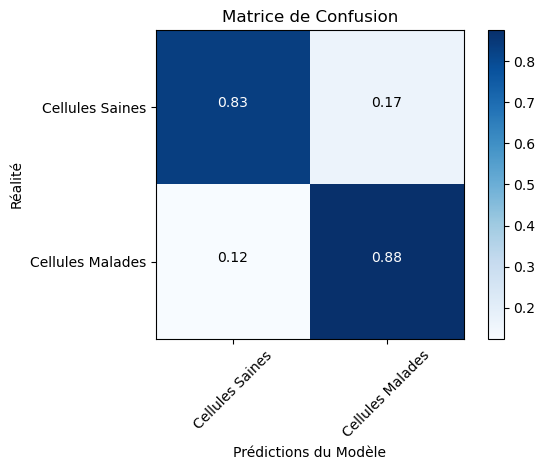

In [8]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Matrice de Confusion', cmap=plt.cm.Blues):
    """
    Cette fonction affiche la matrice de confusion.
    Normalisation peut être appliquée en définissant `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Matrice de confusion normalisée")
    else:
        print('Matrice de confusion, sans normalisation')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Réalité')
    plt.xlabel('Prédictions du Modèle')
    plt.tight_layout()

# Exemple d'utilisation
cm = np.array([[50, 10], [5, 35]])  # Exemple de matrice de confusion
classes = ['Cellules Saines', 'Cellules Malades']
plot_confusion_matrix(cm, classes, normalize=True)
plt.show()

#### ROC-AUC

In [10]:
def roc_auc(y_true, y_scores):
    """
    Compute the ROC AUC score.

    Parameters:
    y_true (list): True binary labels (0 or 1).
    y_scores (list): Target scores, can either be probability estimates of the positive class, confidence values, or non-thresholded measure of decisions.

    Returns:
    float: The ROC AUC score.
    """
    from sklearn.metrics import roc_auc_score
    return roc_auc_score(y_true, y_scores)

# Exemple d'utilisation
y_true = [0, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8]  # Probabilités prédites pour la classe positive
auc_score = roc_auc(y_true, y_scores)
print(f"ROC AUC Score: {auc_score}")

ROC AUC Score: 0.75


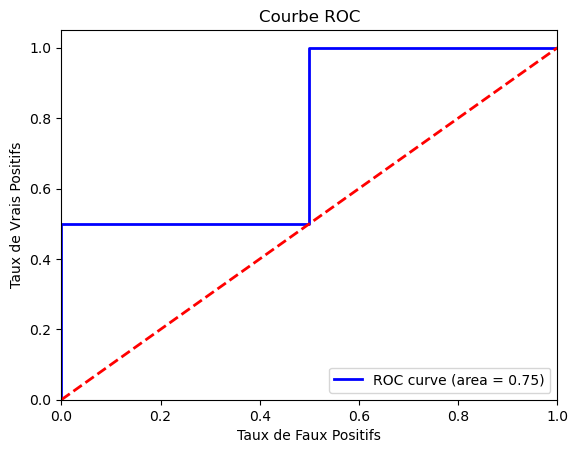

In [11]:
def plot_roc_curve(y_true, y_scores):
    """
    Plot the ROC curve.

    Parameters:
    y_true (list): True binary labels (0 or 1).
    y_scores (list): Target scores, can either be probability estimates of the positive class, confidence values, or non-thresholded measure of decisions.
    """
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_true, y_scores))
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs')
    plt.ylabel('Taux de Vrais Positifs')
    plt.title('Courbe ROC')
    plt.legend(loc="lower right")
    plt.show()

# Exemple d'utilisation
y_true = [0, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8]  # Probabilités prédites pour la classe positive
plot_roc_curve(y_true, y_scores)